## **Classification task: Classical Classification on CIFAR-10**

In [1]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf cifar-10-python.tar.gz

--2026-03-17 09:36:27--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz.5’

cifar-10-python.tar 100%[===================>] 162.60M  44.1MB/s    in 4.1s    

2026-03-17 09:36:32 (40.0 MB/s) - ‘cifar-10-python.tar.gz.5’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [2]:
import pickle
import numpy as np
import os

def unpickle(file):
    """ Standard function to load binary batch files. """
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# 1. Automatic path detection
# This will point to the folder where your notebook is located
current_dir = os.getcwd()
data_dir = '/content/cifar-10-batches-py'

# 2. Check if the directory actually exists before loading
if not os.path.exists(data_dir):
    print(f"Error: The directory {data_dir} was not found!")
    print("Please make sure the folder 'cifar-10-batches-py' is in the same location as this notebook.")
else:
    # 3. Load the first training batch
    file_path = os.path.join(data_dir, 'data_batch_1')
    batch1 = unpickle(file_path)

    # 4. Extract and Reshape
    X_batch = batch1[b'data']
    y_batch = np.array(batch1[b'labels'])

    # Reshape to (N, 3, 32, 32) and then transpose to (N, 32, 32, 3)
    X_batch = X_batch.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)

    print(f"Success! Loaded {X_batch.shape[0]} images.")
    print(f"Image shape: {X_batch.shape[1:]} (Width x Height x Channels)")

Success! Loaded 10000 images.
Image shape: (32, 32, 3) (Width x Height x Channels)


**Baseline Models**

Data Preprocessing & Preparation

In [3]:
# 1. Flatten the images: from (10000, 32, 32, 3) to (10000, 3072)
X_flatten = X_batch.reshape(X_batch.shape[0], -1)

# 2. Normalize the pixel values to range [0, 1]
X_normalized = X_flatten.astype('float32') / 255.0

# 3. Use the labels as they are
y_labels = y_batch

print(f"Data is ready for training.")
print(f"Original shape: {X_batch.shape}")
print(f"Flattened shape: {X_normalized.shape}")

Data is ready for training.
Original shape: (10000, 32, 32, 3)
Flattened shape: (10000, 3072)


In [4]:
from sklearn.model_selection import train_test_split

# Create a single, consistent Train/Validation split (80% Train, 20% Validation)
# This strictly follows the instruction: "Each model must be trained using the same train/validation split"
X_train_val, X_val, y_train_val, y_val = train_test_split(
    X_normalized, y_labels, test_size=0.2, random_state=42
)

print(f"Consistent split created")
print(f"Training set size: {X_train_val.shape[0]} images")
print(f"Validation set size: {X_val.shape[0]} images")

Consistent split created
Training set size: 8000 images
Validation set size: 2000 images


 Multiclass Logistic Regression (Softmax)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Define the baseline model using Multinomial (Softmax)
# Changed solver to 'saga' which is much faster for large image datasets
softmax_model = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=200, random_state=42, n_jobs=-1)

# 2. Train the model ONLY on the Training set!
softmax_model.fit(X_train_val, y_train_val)

# 3. Make predictions on the VALIDATION set
y_val_pred_softmax = softmax_model.predict(X_val)

# 4. Evaluate the performance on the Validation set
accuracy_softmax = accuracy_score(y_val, y_val_pred_softmax)
print(f"Baseline Softmax Validation Accuracy: {accuracy_softmax * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Softmax Validation Accuracy: 35.85%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Linear Support Vector Machine (SVM)

In [6]:
from sklearn.svm import LinearSVC

# Define the Linear SVM model
# We use dual=False because we have more samples than features
svm_model = LinearSVC(dual=False, max_iter=1000, verbose=1)

# Train the model on the full normalized batch
svm_model.fit(X_train_val, y_train_val)

# Predict and Evaluate
y_val_pred_svm = svm_model.predict(X_val)
acc_svm = accuracy_score(y_val, y_val_pred_svm)

print(f"Linear SVM Accuracy: {acc_svm * 100:.2f}%")

[LibLinear]Linear SVM Accuracy: 28.15%


K-Nearest Neighbors (KNN)

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Define the KNN model with k=5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Training is almost instant for KNN
knn_model.fit(X_train_val, y_train_val)

# Predicting on a sample to get a quick result
# KNN prediction is computationally expensive on large datasets
y_pred_knn = knn_model.predict(X_val)
acc_knn = accuracy_score(y_val, y_pred_knn)

print(f"K-Nearest Neighbors (KNN) Accuracy on sample: {acc_knn * 100:.2f}%")

K-Nearest Neighbors (KNN) Accuracy on sample: 28.40%


 **Hyperparameter Selection**





Hyperparameter Selection - Softmax (Regularization C)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.01, accuracy = 0.4050


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.1, accuracy = 0.3910


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 1, accuracy = 0.3755


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 10, accuracy = 0.3745


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C = 100, accuracy = 0.3750


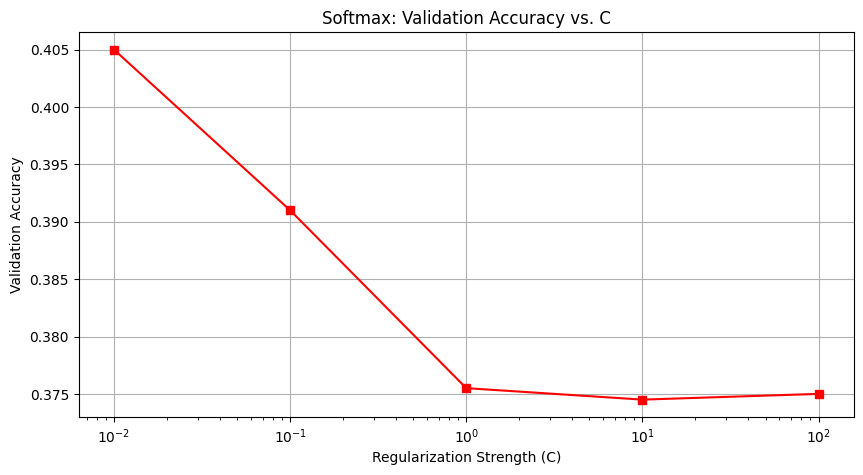

The best C value for Softmax is: 0.01


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.01, max_iter=200, multi_class='multinomial',
                   solver='saga')

In [8]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

c_values = [0.01, 0.1, 1, 10, 100]
softmax_accuracies = []

for c in c_values:
    # Using a smaller max_iter for speed during selection
    # Using saga solver as it's often faster for large sparse datasets
    model = LogisticRegression(multi_class='multinomial', solver='saga', C=c, max_iter=100)

    # Train on the consistent Training set
    model.fit(X_train_val, y_train_val)

    # Validate on the consistent Validation set
    acc = accuracy_score(y_val, model.predict(X_val))
    softmax_accuracies.append(acc)

    print(f"C = {c}, accuracy = {acc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(c_values, softmax_accuracies, marker='s', color='red')
plt.xscale('log') # Log scale is better for C values
plt.title('Softmax: Validation Accuracy vs. C')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

# Select the best C and train the final baseline Softmax model
best_c_softmax = c_values[np.argmax(softmax_accuracies)]
print(f"The best C value for Softmax is: {best_c_softmax}")

# Retrain the model with the best C for later use on the test set
softmax_model = LogisticRegression(multi_class='multinomial', solver='saga', C=best_c_softmax, max_iter=200)
softmax_model.fit(X_train_val, y_train_val)

Hyperparameter Selection - Linear SVM

SVM C=0.01: Accuracy = 0.3780
SVM C=0.1: Accuracy = 0.3185
SVM C=1: Accuracy = 0.2815
SVM C=10: Accuracy = 0.2605


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM C=100: Accuracy = 0.2375


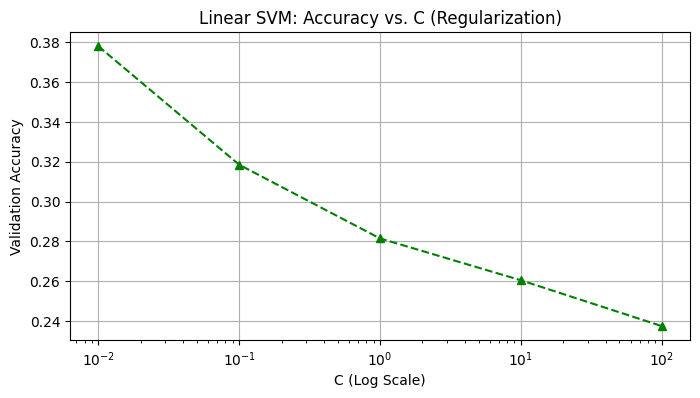

SVM C=0.01: Accuracy = 0.3780
SVM C=0.1: Accuracy = 0.3185


In [9]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Defining the missing variables for this cell
c_values = [0.01, 0.1, 1, 10, 100]
svm_accs = []

for c in c_values:
    # Training on 5,000 samples and validating on 1,000 for selection
    model = LinearSVC(dual=False, C=c, max_iter=1000)
    model.fit(X_train_val, y_train_val)
    acc = accuracy_score(y_val, model.predict(X_val))
    svm_accs.append(acc)
    print(f"SVM C={c}: Accuracy = {acc:.4f}")

# Plotting the Support Vector Machine results
plt.figure(figsize=(8, 4))
plt.plot(c_values, svm_accs, marker='^', color='green', linestyle='--')
plt.xscale('log')
plt.title('Linear SVM: Accuracy vs. C (Regularization)')
plt.xlabel('C (Log Scale)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

Hyperparameter Selection - KNN (Number of Neighbors k)

Baseline KNN (k=5) Validation Accuracy: 28.40%

Starting Hyperparameter Selection for KNN...
Tested k =  1 | Validation Accuracy = 0.2790
Tested k =  3 | Validation Accuracy = 0.2750
Tested k =  5 | Validation Accuracy = 0.2840
Tested k =  8 | Validation Accuracy = 0.2870
Tested k = 10 | Validation Accuracy = 0.2875
Tested k = 12 | Validation Accuracy = 0.2820
Tested k = 15 | Validation Accuracy = 0.2835
Tested k = 20 | Validation Accuracy = 0.2820


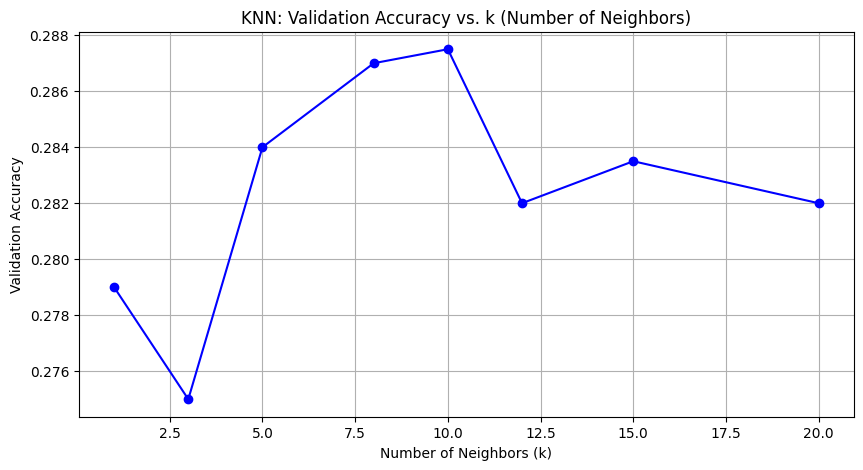


Final Decision: The best k value for KNN is 10


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Define the KNN model with k=5 neighbors as a starting point
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model ONLY on the consistent training set (8,000 images)
# This follows the requirement to use the same split for all models
knn_model.fit(X_train_val, y_train_val)

# Predict on the consistent validation set (2,000 images the model hasn't seen)
y_val_pred_knn = knn_model.predict(X_val)

# Evaluate performance
acc_knn = accuracy_score(y_val, y_val_pred_knn)
print(f"Baseline KNN (k=5) Validation Accuracy: {acc_knn * 100:.2f}%")

# Define range of k values to test [cite: 125, 127]
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]
k_accuracies = []

print("\nStarting Hyperparameter Selection for KNN...")

for k in k_choices:
    # Initialize KNN with current k value
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train on the 80% training split
    knn.fit(X_train_val, y_train_val)

    # Validate on the 20% validation split
    y_pred_k = knn.predict(X_val)
    acc = accuracy_score(y_val, y_pred_k)

    k_accuracies.append(acc)
    print(f"Tested k = {k:2d} | Validation Accuracy = {acc:.4f}")


# Visualization of Results
# Plotting validation accuracy as a function of k
plt.figure(figsize=(10, 5))
plt.plot(k_choices, k_accuracies, marker='o', linestyle='-', color='blue')
plt.title('KNN: Validation Accuracy vs. k (Number of Neighbors)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

# Select and store the best k based on validation performance [cite: 128, 137]
best_k = k_choices[np.argmax(k_accuracies)]
print(f"\nFinal Decision: The best k value for KNN is {best_k}")

Evaluation and Analysis

--- FINAL EVALUATION ---
Final Model (Softmax) Test Accuracy: 0.3911


<Figure size 1000x800 with 0 Axes>

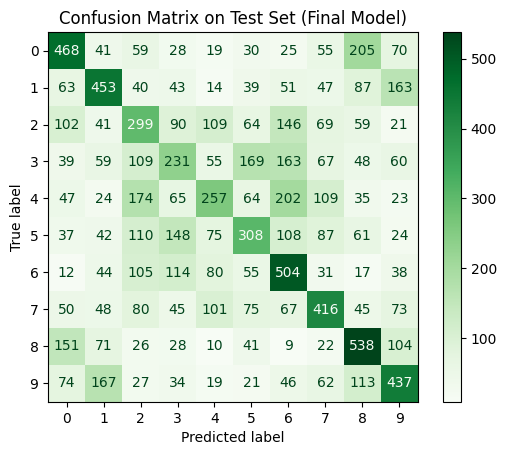

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Loading the Test Set (as required by the instructions)
test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
X_test = test_batch[b'data'].reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).reshape(10000, -1) / 255.0
y_test = np.array(test_batch[b'labels'])

# 2. Final Evaluation on Test Set
# Assuming Softmax was your best model
y_test_pred = softmax_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"--- FINAL EVALUATION ---")
print(f"Final Model (Softmax) Test Accuracy: {test_acc:.4f}")

# 3. Final Confusion Matrix for the Report
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix on Test Set (Final Model)')
plt.show()